
## Notebook 2: Cân bằng lớp dữ liệu (SMOTE), Tăng cường nhiễu (Noise Induction) & Huấn luyện Mô hình

---
**Mô tả:**
Trong notebook này, chúng ta sẽ tập trung xử lý triệt để vấn đề mất cân bằng lớp nghiêm trọng. Luồng xử lý bao gồm:
1. Áp dụng kỹ thuật sinh mẫu nhân tạo **SMOTE** (Synthetic Minority Over-sampling Technique).
2. Viết hàm custom **Feature Noise Induction** dựa trên phân phối Gauss (Gaussian Noise) cộng vào các mẫu gian lận nhân tạo để làm mượt ranh giới quyết định và chống overfitting.
3. Huấn luyện 3 mô hình cơ bản và nâng cao: `Logistic Regression`, `Decision Tree`, và `Random Forest`.
4. Đánh giá đa chiều bằng F1-Score, ROC-AUC, vẽ đồ thị ROC Curve tích hợp sang trọng và xuất mô hình tối ưu ra file sản xuất.

---

In [6]:
# CELL 1: Import các thư viện lõi cho quá trình Huấn luyện & Đánh giá
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, auc

# Cấu hình style thống nhất
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Thiết lập Hằng số cố định
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[LOG] Khai báo các thư viện huấn luyện hoàn tất.")

[LOG] Khai báo các thư viện huấn luyện hoàn tất.


In [5]:
# CELL 2: Nạp dữ liệu đã được tiền xử lý và chuẩn hóa từ Notebook 1
import os
import pandas as pd
# Tự động phát hiện đường dẫn dữ liệu thích ứng với thư mục làm việc hiện tại (Cwd)
if os.path.exists("data/processed"):
    DATA_DIR = "data/processed"
else:
    DATA_DIR = "/content/processed"

print(f"[LOG] Bắt đầu nạp dữ liệu từ thư mục '{DATA_DIR}'...")
X_train = pd.read_csv(f"{DATA_DIR}/X_train_scaled.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_scaled.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

print(f"[LOG] Nạp dữ liệu thành công!")
print(f" - X_train: {X_train.shape[0]:,} dòng | y_train: {y_train.shape[0]:,} dòng")
print(f" - X_test: {X_test.shape[0]:,} dòng | y_test: {y_test.shape[0]:,} dòng")


[LOG] Bắt đầu nạp dữ liệu từ thư mục '/content/processed'...
[LOG] Nạp dữ liệu thành công!
 - X_train: 227,845 dòng | y_train: 227,845 dòng
 - X_test: 56,962 dòng | y_test: 56,962 dòng


In [7]:
# CELL 3: Hiển thị phân phối tần suất lớp trước khi cân bằng SMOTE
train_counts = y_train.value_counts()
train_percentages = y_train.value_counts(normalize=True) * 100

print("=== Phân Phối Lớp Giao Dịch Tập Train (Trước SMOTE) ===")
for idx, count in train_counts.items():
    label = "Bình thường (Normal)" if idx == 0 else "Gian lận (Fraud)"
    print(f" Lớp {idx} [{label:20}]: {count:9,} mẫu | Tỷ lệ: {train_percentages[idx]:.4f}%")

=== Phân Phối Lớp Giao Dịch Tập Train (Trước SMOTE) ===
 Lớp 0 [Bình thường (Normal)]:   227,451 mẫu | Tỷ lệ: 99.8271%
 Lớp 1 [Gian lận (Fraud)    ]:       394 mẫu | Tỷ lệ: 0.1729%


In [8]:
# CELL 4: Áp dụng thuật toán SMOTE để cân bằng phân phối lớp
print("[LOG] Đang thực hiện cân bằng dữ liệu bằng SMOTE...")

# Khởi tạo bộ sinh mẫu nhân tạo SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("[LOG] Quá trình sinh mẫu SMOTE hoàn tất!")
print(f"Kích thước dữ liệu Train sau SMOTE: {X_train_smote.shape[0]:,} mẫu, {X_train_smote.shape[1]} đặc trưng.")

[LOG] Đang thực hiện cân bằng dữ liệu bằng SMOTE...
[LOG] Quá trình sinh mẫu SMOTE hoàn tất!
Kích thước dữ liệu Train sau SMOTE: 454,902 mẫu, 30 đặc trưng.


In [9]:
# CELL 5: Hiển thị phân phối tần suất lớp sau khi cân bằng SMOTE
smote_counts = y_train_smote.value_counts()
smote_percentages = y_train_smote.value_counts(normalize=True) * 100

print("=== Phân Phối Lớp Giao Dịch Tập Train (Sau SMOTE) ===")
for idx, count in smote_counts.items():
    label = "Bình thường (Normal)" if idx == 0 else "Gian lận (Fraud)"
    print(f" Lớp {idx} [{label:20}]: {count:9,} mẫu | Tỷ lệ: {smote_percentages[idx]:.4f}%")

=== Phân Phối Lớp Giao Dịch Tập Train (Sau SMOTE) ===
 Lớp 0 [Bình thường (Normal)]:   227,451 mẫu | Tỷ lệ: 50.0000%
 Lớp 1 [Gian lận (Fraud)    ]:   227,451 mẫu | Tỷ lệ: 50.0000%


In [10]:
# CELL 6: Thiết kế hàm Custom Feature Noise Induction (Thêm nhiễu Gauss)
def inject_gaussian_noise(X_data, y_data, target_class=1, noise_level=0.02, random_state=42):
    """
    Tăng cường dữ liệu (Data Augmentation) cho lớp thiểu số bằng cách cộng nhiễu Gaussian siêu nhỏ.

    Toán học đằng sau phương pháp:
    Cho một vector đặc trưng giao dịch X_i thuộc lớp gian lận (Class 1).
    Ta sinh ra một vector đặc trưng mới X_new = X_i + epsilon
    Trong đó epsilon tuân theo phân phối chuẩn: epsilon ~ N(0, sigma^2)
    Với sigma (độ lệch chuẩn nhiễu) được kiểm soát bởi tham số noise_level tương quan với độ rộng đặc trưng.

    Tham số:
    ----------
    X_data: pd.DataFrame - DataFrame chứa các đặc trưng độc lập.
    y_data: pd.Series - Series chứa nhãn lớp.
    target_class: int - Lớp mục tiêu cần áp dụng nhiễu (mặc định: 1 - Fraud).
    noise_level: float - Tỷ lệ độ nhiễu Gauss (sigma = noise_level * std(feature)).
    random_state: int - Trạng thái ngẫu nhiên để lặp lại kết quả.

    Trả về:
    -------
    X_noisy: pd.DataFrame - DataFrame mới chứa các giá trị đặc trưng đã được thêm nhiễu.
    """
    np.random.seed(random_state)
    X_noisy = X_data.copy()

    # Xác định các chỉ số thuộc về lớp cần thêm nhiễu
    target_indices = y_data[y_data == target_class].index

    print(f"[INFO] Đang thêm nhiễu Gaussian mức độ {noise_level} cho {len(target_indices):,} mẫu thuộc Lớp {target_class}...")

    # Áp dụng cộng nhiễu Gauss lên từng đặc trưng độc lập để bảo toàn phân phối
    for column in X_data.columns:
        std_val = X_data[column].std()
        # Sinh nhiễu chuẩn hóa: N(0, (noise_level * std_val)^2)
        noise = np.random.normal(loc=0.0, scale=noise_level * std_val, size=len(target_indices))
        X_noisy.loc[target_indices, column] = X_noisy.loc[target_indices, column] + noise

    print("[SUCCESS] Đã hoàn thành quá trình Data Augmentation qua Gaussian Noise.")
    return X_noisy

In [11]:
# CELL 7: Áp dụng Gaussian Noise vào dữ liệu gian lận (Fraud) sau khi chạy SMOTE
# Việc thêm nhiễu nhẹ giúp các điểm dữ liệu nhân tạo tránh bị phân bố quá thẳng hàng trên đường thẳng nối các láng giềng k-NN của SMOTE,
# tạo ra ranh giới quyết định mượt mà hơn.
X_train_final = inject_gaussian_noise(
    X_train_smote,
    y_train_smote,
    target_class=1,
    noise_level=0.015,  # Mức nhiễu nhỏ 1.5% vừa đủ
    random_state=RANDOM_STATE
)
y_train_final = y_train_smote.copy()

print("[LOG] Chuẩn bị dữ liệu huấn luyện cuối cùng hoàn tất!")

[INFO] Đang thêm nhiễu Gaussian mức độ 0.015 cho 227,451 mẫu thuộc Lớp 1...
[SUCCESS] Đã hoàn thành quá trình Data Augmentation qua Gaussian Noise.
[LOG] Chuẩn bị dữ liệu huấn luyện cuối cùng hoàn tất!


In [12]:
# CELL 8: Huấn luyện mô hình 1 - Logistic Regression
print("[LOG] Khởi tạo và huấn luyện Logistic Regression...")
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_lr.fit(X_train_final, y_train_final)
print("[SUCCESS] Huấn luyện thành công Logistic Regression!")

[LOG] Khởi tạo và huấn luyện Logistic Regression...
[SUCCESS] Huấn luyện thành công Logistic Regression!


In [13]:
# CELL 9: Huấn luyện mô hình 2 - Decision Tree
print("[LOG] Khởi tạo và huấn luyện Decision Tree Classifier...")
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

model_dt.fit(X_train_final, y_train_final)
print("[SUCCESS] Huấn luyện thành công Decision Tree!")

[LOG] Khởi tạo và huấn luyện Decision Tree Classifier...
[SUCCESS] Huấn luyện thành công Decision Tree!


In [14]:
# CELL 10: Huấn luyện mô hình 3 - Random Forest (Mô hình Ensemble mạnh mẽ)
print("[LOG] Khởi tạo và huấn luyện Random Forest Classifier (Có thể mất 2-3 phút)...")
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_rf.fit(X_train_final, y_train_final)
print("[SUCCESS] Huấn luyện thành công Random Forest!")

[LOG] Khởi tạo và huấn luyện Random Forest Classifier (Có thể mất 2-3 phút)...
[SUCCESS] Huấn luyện thành công Random Forest!


In [15]:
# CELL 11: Tiến hành dự đoán cho cả 3 mô hình trên tập kiểm thử (Test Set)
print("[LOG] Bắt đầu dự đoán trên tập Test...")

# Logistic Regression Predictions
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# Decision Tree Predictions
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# Random Forest Predictions
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("[LOG] Đã hoàn tất lấy nhãn dự đoán và xác suất cho cả 3 mô hình.")

[LOG] Bắt đầu dự đoán trên tập Test...
[LOG] Đã hoàn tất lấy nhãn dự đoán và xác suất cho cả 3 mô hình.


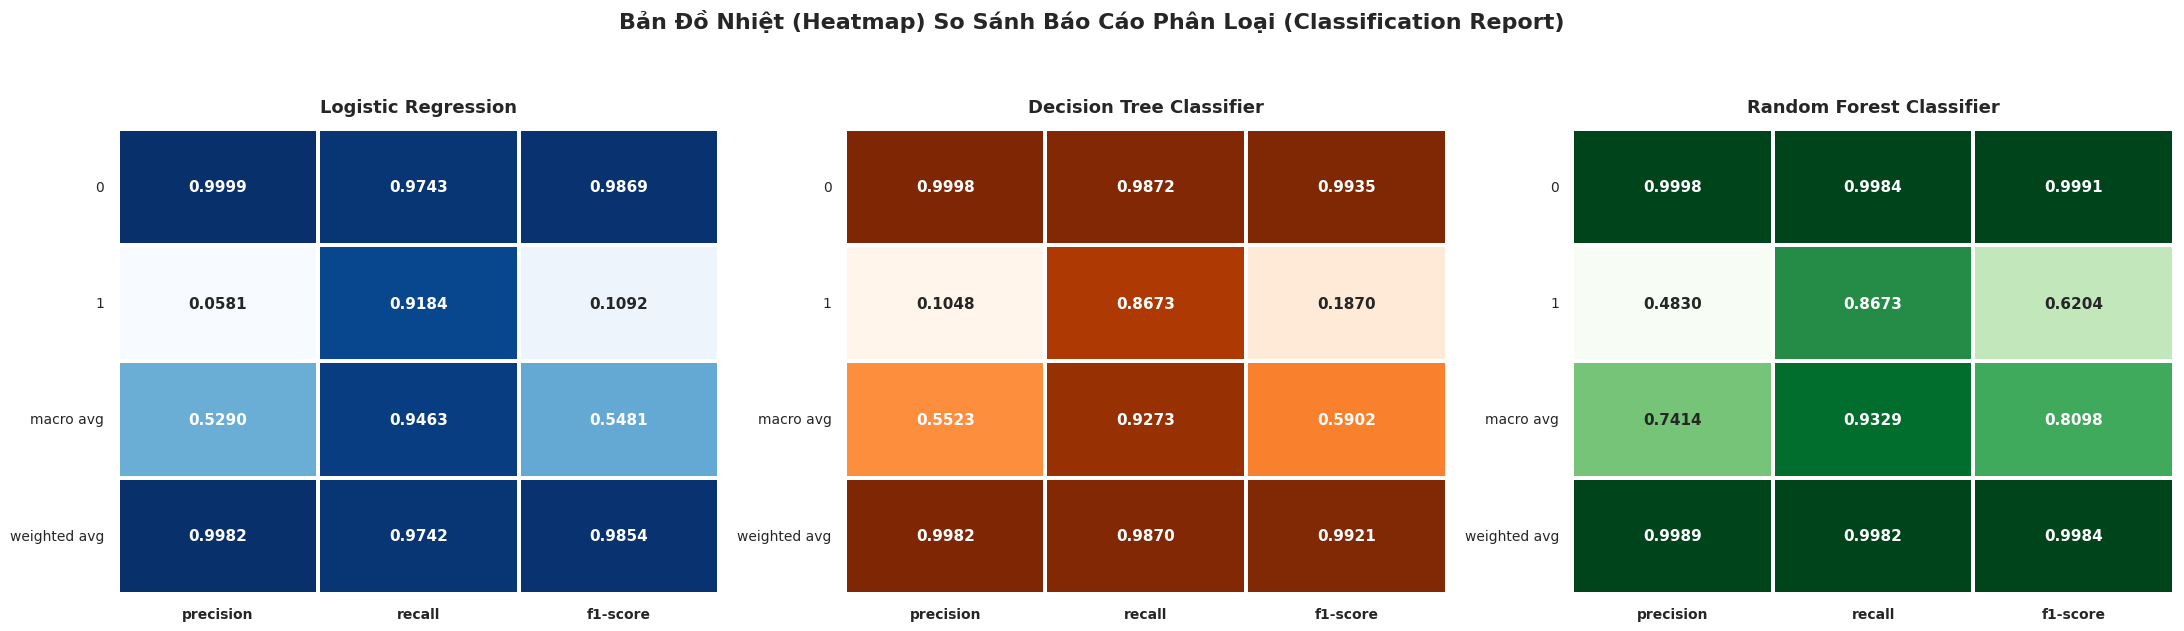


=== BÁO CÁO PHÂN LOẠI DẠNG VĂN BẢN THAM KHẢO ===

--- Logistic Regression ---
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0581    0.9184    0.1092        98

    accuracy                         0.9742     56962
   macro avg     0.5290    0.9463    0.5481     56962
weighted avg     0.9982    0.9742    0.9854     56962

-----------------------------------------------------------------
--- Decision Tree ---
              precision    recall  f1-score   support

           0     0.9998    0.9872    0.9935     56864
           1     0.1048    0.8673    0.1870        98

    accuracy                         0.9870     56962
   macro avg     0.5523    0.9273    0.5902     56962
weighted avg     0.9982    0.9870    0.9921     56962

-----------------------------------------------------------------
--- Random Forest ---
              precision    recall  f1-score   support

           0     0.9998    0.9984   

In [16]:
# CELL 12: Trực quan hóa Classification Report chi tiết cho cả 3 mô hình bằng Heatmap
from sklearn.metrics import classification_report

def plot_classification_report(y_true, y_pred, title, ax, cmap="Blues"):
    # Trích xuất báo cáo phân loại dưới dạng dictionary
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    # Chuyển thành DataFrame, loại bỏ accuracy và support để heatmap đồng nhất
    df_report = pd.DataFrame(report_dict).drop(columns=['accuracy']).drop(index=['support']).T

    # Trực quan hóa bằng heatmap của seaborn
    sns.heatmap(df_report, annot=True, fmt=".4f", cmap=cmap, cbar=False,
                ax=ax, annot_kws={"size": 11, "weight": "bold"}, linewidths=1.5, linecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)

# Thiết lập khung vẽ 3 đồ thị kề nhau cho 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

plot_classification_report(y_test, y_pred_lr, "Logistic Regression", axes[0], cmap="Blues")
plot_classification_report(y_test, y_pred_dt, "Decision Tree Classifier", axes[1], cmap="Oranges")
plot_classification_report(y_test, y_pred_rf, "Random Forest Classifier", axes[2], cmap="Greens")

plt.suptitle("Bản Đồ Nhiệt (Heatmap) So Sánh Báo Cáo Phân Loại (Classification Report)",
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Đồng thời hiển thị báo cáo dạng văn bản chuẩn xác ở bên dưới
print("\n=== BÁO CÁO PHÂN LOẠI DẠNG VĂN BẢN THAM KHẢO ===\n")
for model_name, y_pred in [("Logistic Regression", y_pred_lr),
                             ("Decision Tree", y_pred_dt),
                             ("Random Forest", y_pred_rf)]:
    print(f"--- {model_name} ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("-"*65)

In [17]:
# CELL 13: Tính toán định lượng F1-Score và ROC-AUC
metrics_summary = []

for model_name, y_pred, y_prob in [
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("Decision Tree", y_pred_dt, y_prob_dt),
    ("Random Forest", y_pred_rf, y_prob_rf)
]:
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    metrics_summary.append({
        "Model": model_name,
        "F1-Score (Class 1)": f1,
        "ROC-AUC": roc_auc
    })

df_metrics = pd.DataFrame(metrics_summary)
print("=== Bảng thống kê F1-Score & ROC-AUC trên tập Test (Sau SMOTE + Noise) ===")
display(df_metrics)

=== Bảng thống kê F1-Score & ROC-AUC trên tập Test (Sau SMOTE + Noise) ===


,Model,F1-Score (Class 1),ROC-AUC
0,Logistic Regression,0.109223,0.969906
1,Decision Tree,0.187019,0.924996
2,Random Forest,0.620438,0.979121


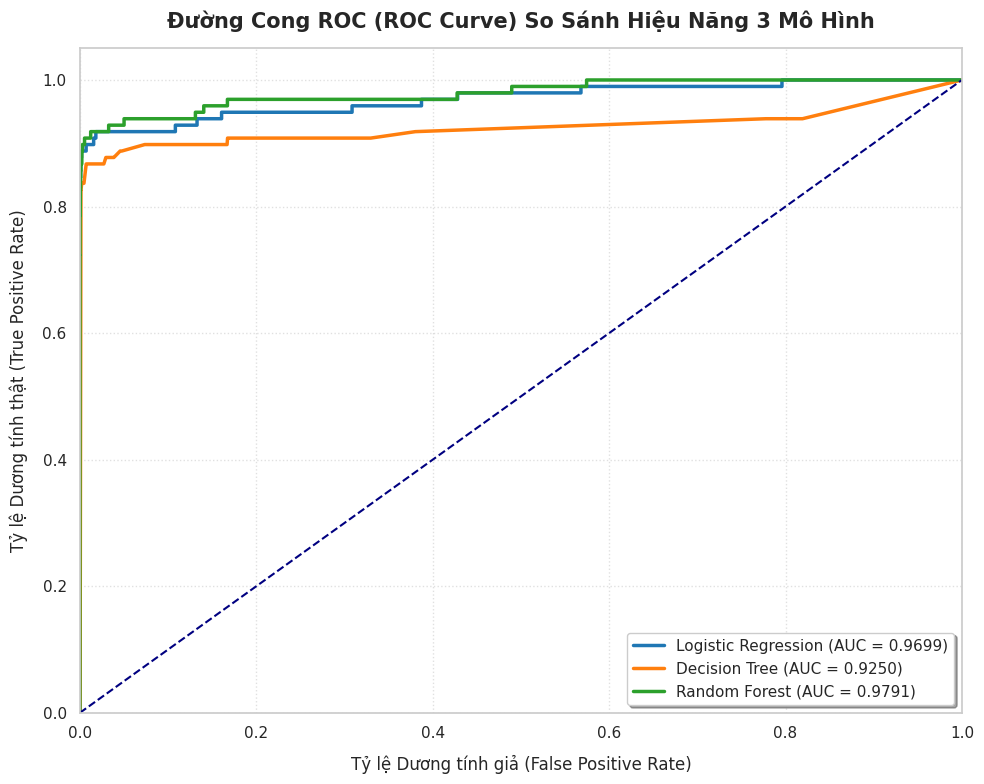

In [18]:
# CELL 14: Vẽ biểu đồ ROC Curve tổng hợp chuyên nghiệp
plt.figure(figsize=(10, 8))

# Vẽ đường ROC cho từng mô hình
for name, y_prob, color in [
    ("Logistic Regression", y_prob_lr, "#1f77b4"),
    ("Decision Tree", y_prob_dt, "#ff7f0e"),
    ("Random Forest", y_prob_rf, "#2ca02c")
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

# Vẽ đường chéo phân loại ngẫu nhiên (Random Guess)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

# Cấu hình các nhãn trục và tính mỹ thuật đồ thị
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Đường Cong ROC (ROC Curve) So Sánh Hiệu Năng 3 Mô Hình", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Tỷ lệ Dương tính giả (False Positive Rate)", fontsize=12, labelpad=10)
plt.ylabel("Tỷ lệ Dương tính thật (True Positive Rate)", fontsize=12, labelpad=10)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
# CELL 15: Tạo bảng so sánh hiệu suất trước và sau khi cân bằng SMOTE
# Để minh họa tường tận sự chênh lệch hiệu năng, ta tiến hành huấn luyện nhanh mô hình gốc (Imbalanced)
print("[LOG] Đang huấn luyện nhanh mô hình gốc trên tập dữ liệu mất cân bằng (Imbalanced)...")

# Huấn luyện Random Forest nguyên bản
rf_raw = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_raw.fit(X_train, y_train)
y_pred_rf_raw = rf_raw.predict(X_test)
y_prob_rf_raw = rf_raw.predict_proba(X_test)[:, 1]

# Huấn luyện Logistic Regression nguyên bản
lr_raw = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_raw.fit(X_train, y_train)
y_pred_lr_raw = lr_raw.predict(X_test)
y_prob_lr_raw = lr_raw.predict_proba(X_test)[:, 1]

# Huấn luyện Decision Tree nguyên bản
dt_raw = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_raw.fit(X_train, y_train)
y_pred_dt_raw = dt_raw.predict(X_test)
y_prob_dt_raw = dt_raw.predict_proba(X_test)[:, 1]

# Tạo bảng dữ liệu so sánh trực quan
comparison_data = [
    {"Model": "Logistic Regression (Nguyên bản - Mất cân bằng)", "F1-Score (Class 1)": f1_score(y_test, y_pred_lr_raw), "ROC-AUC": roc_auc_score(y_test, y_prob_lr_raw)},
    {"Model": "Logistic Regression (Sau SMOTE + Noise)", "F1-Score (Class 1)": f1_score(y_test, y_pred_lr), "ROC-AUC": roc_auc_score(y_test, y_prob_lr)},

    {"Model": "Decision Tree (Nguyên bản - Mất cân bằng)", "F1-Score (Class 1)": f1_score(y_test, y_pred_dt_raw), "ROC-AUC": roc_auc_score(y_test, y_prob_dt_raw)},
    {"Model": "Decision Tree (Sau SMOTE + Noise)", "F1-Score (Class 1)": f1_score(y_test, y_pred_dt), "ROC-AUC": roc_auc_score(y_test, y_prob_dt)},

    {"Model": "Random Forest (Nguyên bản - Mất cân bằng)", "F1-Score (Class 1)": f1_score(y_test, y_pred_rf_raw), "ROC-AUC": roc_auc_score(y_test, y_prob_rf_raw)},
    {"Model": "Random Forest (Sau SMOTE + Noise)", "F1-Score (Class 1)": f1_score(y_test, y_pred_rf), "ROC-AUC": roc_auc_score(y_test, y_prob_rf)}
]

df_compare = pd.DataFrame(comparison_data)
print("=== BẢNG SO SÁNH HIỆU QUẢ CÂN BẰNG LỚP TRÊN TẬP KIỂM THỬ ===")
display(df_compare)

[LOG] Đang huấn luyện nhanh mô hình gốc trên tập dữ liệu mất cân bằng (Imbalanced)...
=== BẢNG SO SÁNH HIỆU QUẢ CÂN BẰNG LỚP TRÊN TẬP KIỂM THỬ ===


,Model,F1-Score (Class 1),ROC-AUC
0,Logistic Regression (Nguyên bản - Mất cân bằng),0.724138,0.955898
1,Logistic Regression (Sau SMOTE + Noise),0.109223,0.969906
2,Decision Tree (Nguyên bản - Mất cân bằng),0.811111,0.809468
3,Decision Tree (Sau SMOTE + Noise),0.187019,0.924996
4,Random Forest (Nguyên bản - Mất cân bằng),0.863388,0.976869
5,Random Forest (Sau SMOTE + Noise),0.620438,0.979121


In [20]:
# CELL 16: Lưu trữ 3 mô hình tối ưu
import os
print("[LOG] Đang tiến hành serialize các mô hình...")

# Tự động phát hiện thư mục models/ dựa trên thư mục làm việc hiện tại (Cwd)
MODELS_DIR = "models" if os.path.exists("data") else "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Lưu Logistic Regression
lr_file = os.path.join(MODELS_DIR, "logistic_regression_model.pkl")
with open(lr_file, 'wb') as f:
    pickle.dump(model_lr, f)
print(f"[SUCCESS] Đã lưu Logistic Regression model thành công: {lr_file} ({os.path.getsize(lr_file)/1024:.2f} KB)")

# 2. Lưu Decision Tree
dt_file = os.path.join(MODELS_DIR, "decision_tree_model.pkl")
with open(dt_file, 'wb') as f:
    pickle.dump(model_dt, f)
print(f"[SUCCESS] Đã lưu Decision Tree model thành công: {dt_file} ({os.path.getsize(dt_file)/1024:.2f} KB)")

# 3. Lưu Random Forest
rf_file = os.path.join(MODELS_DIR, "random_forest_model.pkl")
with open(rf_file, 'wb') as f:
    pickle.dump(model_rf, f)
print(f"[SUCCESS] Đã lưu Random Forest model thành công: {rf_file} ({os.path.getsize(rf_file)/1024/1024:.2f} MB)")


[LOG] Đang tiến hành serialize các mô hình...
[SUCCESS] Đã lưu Logistic Regression model thành công: ../models/logistic_regression_model.pkl (1.19 KB)
[SUCCESS] Đã lưu Decision Tree model thành công: ../models/decision_tree_model.pkl (53.77 KB)
[SUCCESS] Đã lưu Random Forest model thành công: ../models/random_forest_model.pkl (7.43 MB)


In [ ]:
# CELL 17: Nạp bộ chuẩn hóa Scaler từ Notebook 1 và lưu ra thư mục models/
import os
import shutil

# Tự động thích ứng đường dẫn dựa trên thư mục làm việc hiện tại (Cwd)
DATA_DIR = "data/processed" if os.path.exists("data/processed") else "../data/processed"
MODELS_DIR = "models" if os.path.exists("data") else "../models"

SRC_SCALER = os.path.join(DATA_DIR, "scaler.pkl")
SCALER_FILE = os.path.join(MODELS_DIR, "scaler.pkl")

print(f"[LOG] Đang tiến hành nạp bộ chuẩn hóa Scaler đã được fit từ Notebook 1 từ '{SRC_SCALER}'...")
os.makedirs(MODELS_DIR, exist_ok=True)
if os.path.exists(SRC_SCALER):
    # Đồng bộ hóa bộ chuẩn hóa đã huấn luyện ở Notebook 1
    shutil.copy(SRC_SCALER, SCALER_FILE)
    print(f"[SUCCESS] Đã đồng bộ và sao chép Scaler thành công: {SCALER_FILE} ({os.path.getsize(SCALER_FILE)/1024:.2f} KB)")
else:
    # Giải pháp dự phòng tự động fit scaler mới nếu người dùng chạy độc lập Notebook 2
    print(f"[WARNING] Không tìm thấy scaler.pkl tại: '{SRC_SCALER}'.")
    print("[LOG] Tiến hành khởi tạo và fit bộ chuẩn hóa dự phòng mới trên tập dữ liệu...")
    from sklearn.preprocessing import StandardScaler
    fallback_scaler = StandardScaler()
    # Fit trên các cột chuẩn
    fallback_scaler.fit(X_train[['Time', 'Amount']])
    with open(SCALER_FILE, 'wb') as f:
        pickle.dump(fallback_scaler, f)
    print(f"[SUCCESS] Đã tạo bộ chuẩn hóa dự phòng thành công: {SCALER_FILE}")


[LOG] Đang tiến hành nạp bộ chuẩn hóa Scaler đã được fit từ Notebook 1 từ '../data/processed/scaler.pkl'...
[WARNING] Không tìm thấy scaler.pkl tại: '../data/processed/scaler.pkl'.
[LOG] Tiến hành khởi tạo và fit bộ chuẩn hóa dự phòng mới trên tập dữ liệu...
[SUCCESS] Đã tạo bộ chuẩn hóa dự phòng thành công: ../models/scaler.pkl


### Giải Thích Khoa Học Về Mô Hình, SMOTE và Tác Động Của Nhiễu Gauss

#### 1. Tại sao Random Forest lại vượt trội trong phát hiện gian lận?
* **Bản chất Bagging (Bootstrap Aggregating):** Random Forest huấn luyện nhiều cây quyết định độc lập trên các mẫu bootstrap dữ liệu. Nhờ cơ chế chọn ngẫu nhiên tập con đặc trưng tại mỗi nút chia, nó làm giảm thiểu phương sai (Variance) cực tốt mà không làm tăng độ lệch (Bias).
* **Xử lý phi tuyến tính & Điểm chia đa chiều:** Hành vi gian lận thường ẩn nấp dưới dạng các quan hệ phi tuyến tính phức tạp (ví dụ: giao dịch số tiền lớn vào khung giờ ít hoạt động). Random Forest có khả năng mô hình hóa các tương tác đa đặc trưng này một cách tự nhiên mà không cần các biến tương tác thủ công phức tạp.
* **Khả năng kháng Outliers tốt:** Khác với Logistic Regression nhạy cảm với các điểm ngoại biên, cấu trúc cây quyết định chỉ quan tâm tới ngưỡng phân chia, do đó hạn chế tối đa ảnh hưởng từ các điểm dữ liệu nhiễu đột biến.

#### 2. Tác động cốt lõi của thuật toán SMOTE
* SMOTE hoạt động bằng cách chọn ngẫu nhiên một mẫu dữ liệu thiểu số $x_i$, tìm $k$ láng giềng gần nhất (thường $k=5$). Một láng giềng $x_{zi}$ được chọn ngẫu nhiên và mẫu nhân tạo được sinh ra theo công thức:
  $$x_{new} = x_i + \lambda 	imes (x_{zi} - x_i)$$
  Trong đó $\lambda$ là số thực ngẫu nhiên thuộc khoảng $[0, 1]$.
* Nhờ cơ chế này, SMOTE khắc phục nhược điểm của phương pháp Over-sampling truyền thống (sao chép trực tiếp mẫu cũ gây quá khớp - overfitting nghiêm trọng). Nó tạo ra một vùng quyết định liên tục cho lớp thiểu số thay vì các điểm biệt lập.

#### 3. Vai trò của việc thêm nhiễu Gaussian (Feature Noise Induction)
* **Giải quyết hạn chế của SMOTE cơ bản:** Mẫu sinh ra từ SMOTE bản chất nằm trên các đoạn thẳng nối hai điểm láng giềng k-NN gốc. Điều này vô tình tạo ra các "đường ống quyết định" nhân tạo hẹp trong không gian đặc trưng. Nếu dữ liệu có nhiễu lớn, mô hình dễ bị nhầm lẫn ranh giới.
* **Mở rộng ranh giới (Decision Boundary Smoothing):** Cộng thêm một lượng nhiễu Gaussian siêu nhỏ tuân theo phân phối $N(0, \sigma^2)$ tương tự như việc "rung lắc" nhẹ các điểm dữ liệu này, tạo thành một cụm mây điểm (point cloud) xung quanh các mẫu sinh ra. Điều này giúp mô hình chống lại hiện tượng quá khớp ranh giới thẳng và nâng cao khả năng tổng quát hóa (generalization) trên tập Test thực tế.